In [1]:
# These two lines allow for the notebook to automatically update to use the most
# up-to-date versions of the code being imported
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pyphotonicsims.components.elements import *
from pyphotonicsims.box_integration import get_box_path
import h5py

# plt.style.available
%matplotlib inline
plt.style.use('science')
plt.rcParams['figure.figsize'] = [3.5,3]
plt.rcParams['figure.dpi']= 400

## Directional coupler
 - Coupling power
 $$\kappa = \sin{\frac{\pi \delta n L_c}{\lambda}}$$
 - Coupling rate for resonator
 $$\gamma_{ex} = \frac{c\log{1/(1-\kappa^2)}}{n_g L}$$

(0.0, 10.0)

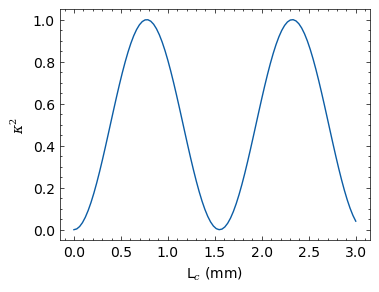

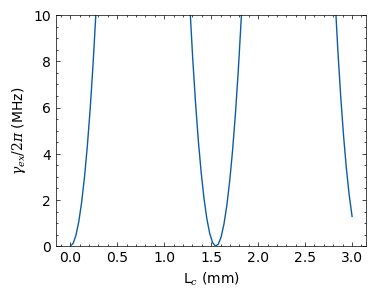

In [2]:
dn = 0.001
L = 1.0
ng = 1.53
wl = 1550e-9
Lc = np.linspace(0, 3e-3, 100)
ka2 = directional_coupler(dn, Lc, wl)
r_ex = cavity_coupling_rate(ka2, ng, L)/(2*np.pi*1e6)

plt.figure()
plt.plot(Lc*1e3, ka2)
plt.xlabel(r'L$_c$ (mm)')
plt.ylabel(r'$\kappa^2$')

plt.figure()
plt.plot(Lc*1e3, r_ex)
plt.xlabel(r'L$_c$ (mm)')
plt.ylabel(r'$\gamma_{ex}/2\pi$ (MHz)')
plt.ylim((0, 10))

### 1550 nm 6 $\mu$m by 80 nm waveguide coupling $\delta n_{eff} $simulations

In [8]:
base_path = 'Simulations/lumerical mode/coupler/6um by 80nm waveguide'
filename = 'coupling_data_1550nm_6umby80nm_sweep_gap_0um_to_6um.mat'
filepath = get_box_path(base_path, filename)
f = h5py.File(filepath, 'r')
dneff = f['dneff'][:]
gapx = f['gap_list'][0]
dneff.shape

(8, 58)

### (1.1) Evaluate $\kappa^2$ by sweeping Lx at gap 2.5 $\mu$m and 2.0 $\mu$m 
 - 2693 mm radius ring resonator with 2.5 $\mu$m gap measures 2.8 MHz coupling rate, corresponding to $\kappa^2 = 0.0017$
 - Point-coupled 4 meter coil resonator (COIL_V4_w1d1, gap 2.5 um Lx 1.0 mm) measures a coupling of 0.9 MH at 1550 nm, corresponding to $\kappa^2=0.11$
 - Two-point-coupled 10 meter coil resonator (COIL_V5_w1d1, gap 2.5 um Lx 1.5 mm) measures a max coupling of 3.2 MH at 1550 nm, corresponding to $\kappa_m^2 = 4\kappa^2(1-\kappa^2) = 0.64 \rightarrow \kappa^2 = 0.20$
 - Two-point-coupled 2 m self-delayeed coil resonator (COIL_V6_w1d1, gap 2.5 um Lx 1.0 mm) measures a coupling loss of 1.74 MH at 1550 nm, corresponding to $\kappa^2 = 0.106$
 - Two-point-coupled 2 meter coil resonator (COIL_V6_w1d1, gap 2.0 um Lx 1.0 mm) measures a max coupling of 8.8 MH at 1550 nm, corresponding to $\kappa_m^2 = 4\kappa^2(1-\kappa^2) = 0.43 \rightarrow \kappa^2 = 0.875$
 - Coupling power $$\kappa_m^2 = 4\kappa^2(1-\kappa^2)$$

#### $\gamma/(2\pi)$ at radius 2693 $\mu$m, gap 2.5 $\mu$m, Lx 0.1 mm

In [18]:
WG_mode_dir = {'TE0': 0, 'TE1': 1, 'TM0': 2, 'TM1': 3}
wl = 1550e-9
ng = 1.54 # for TE0

Text(0.5, 1.0, 'R 2693 $\\mu$m, Lx 0.1 mm')

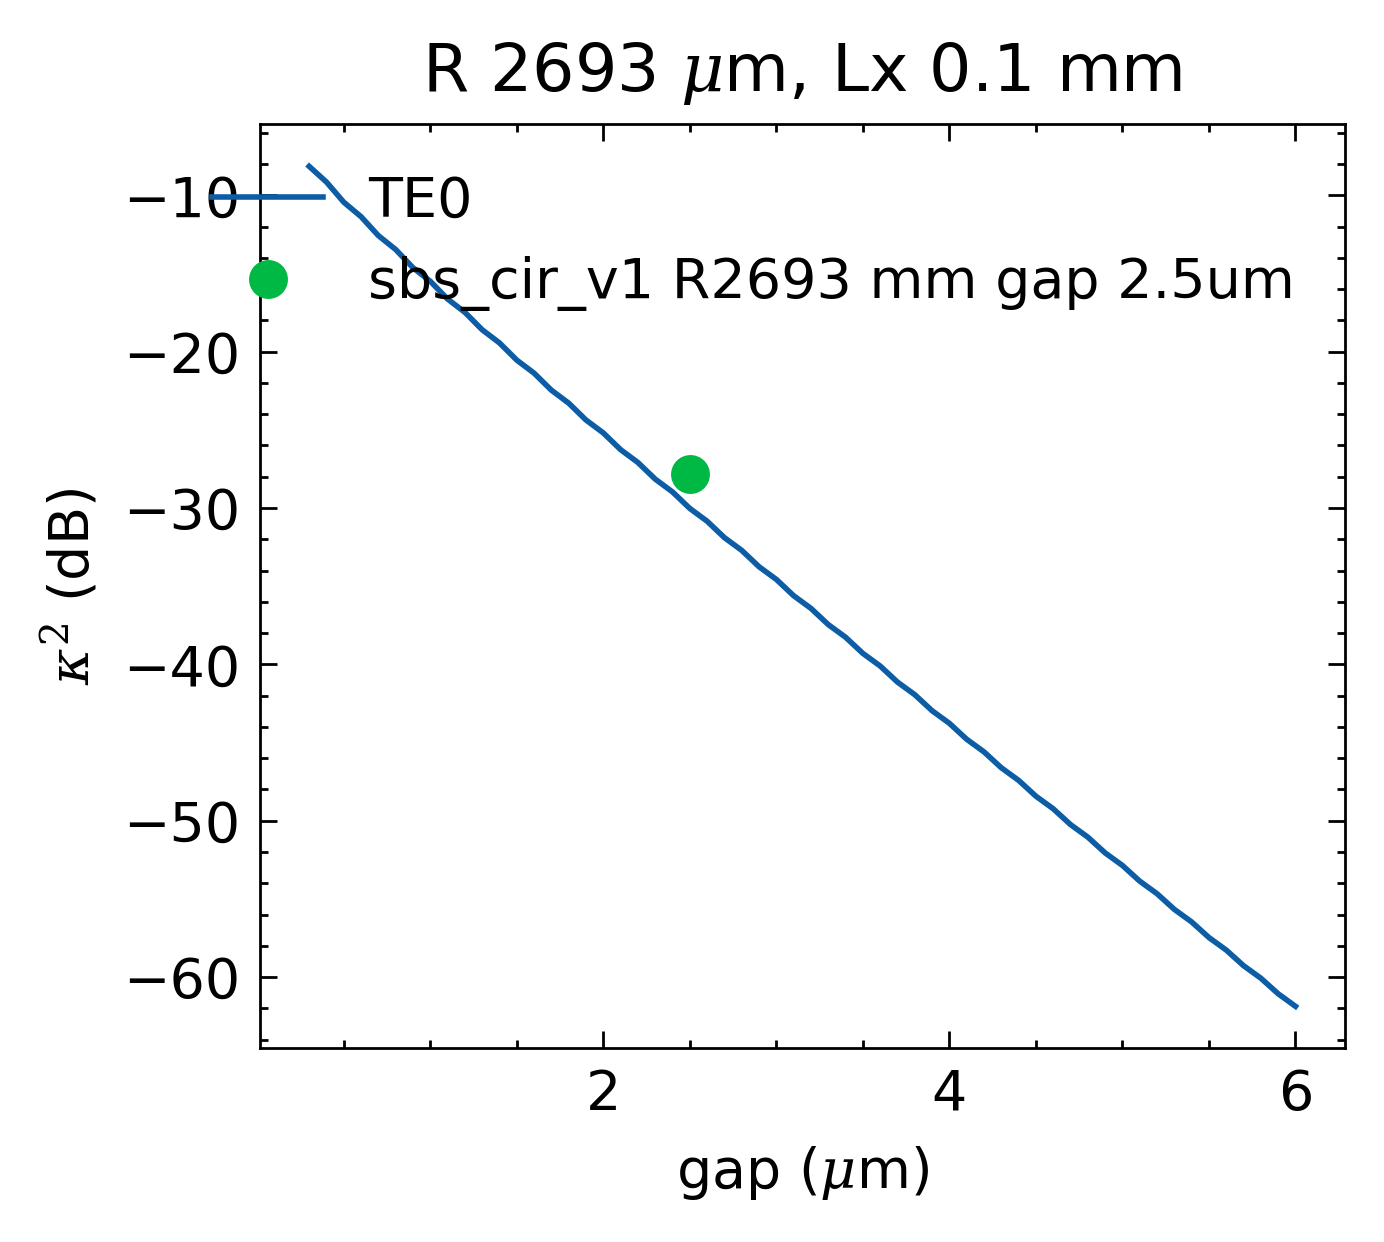

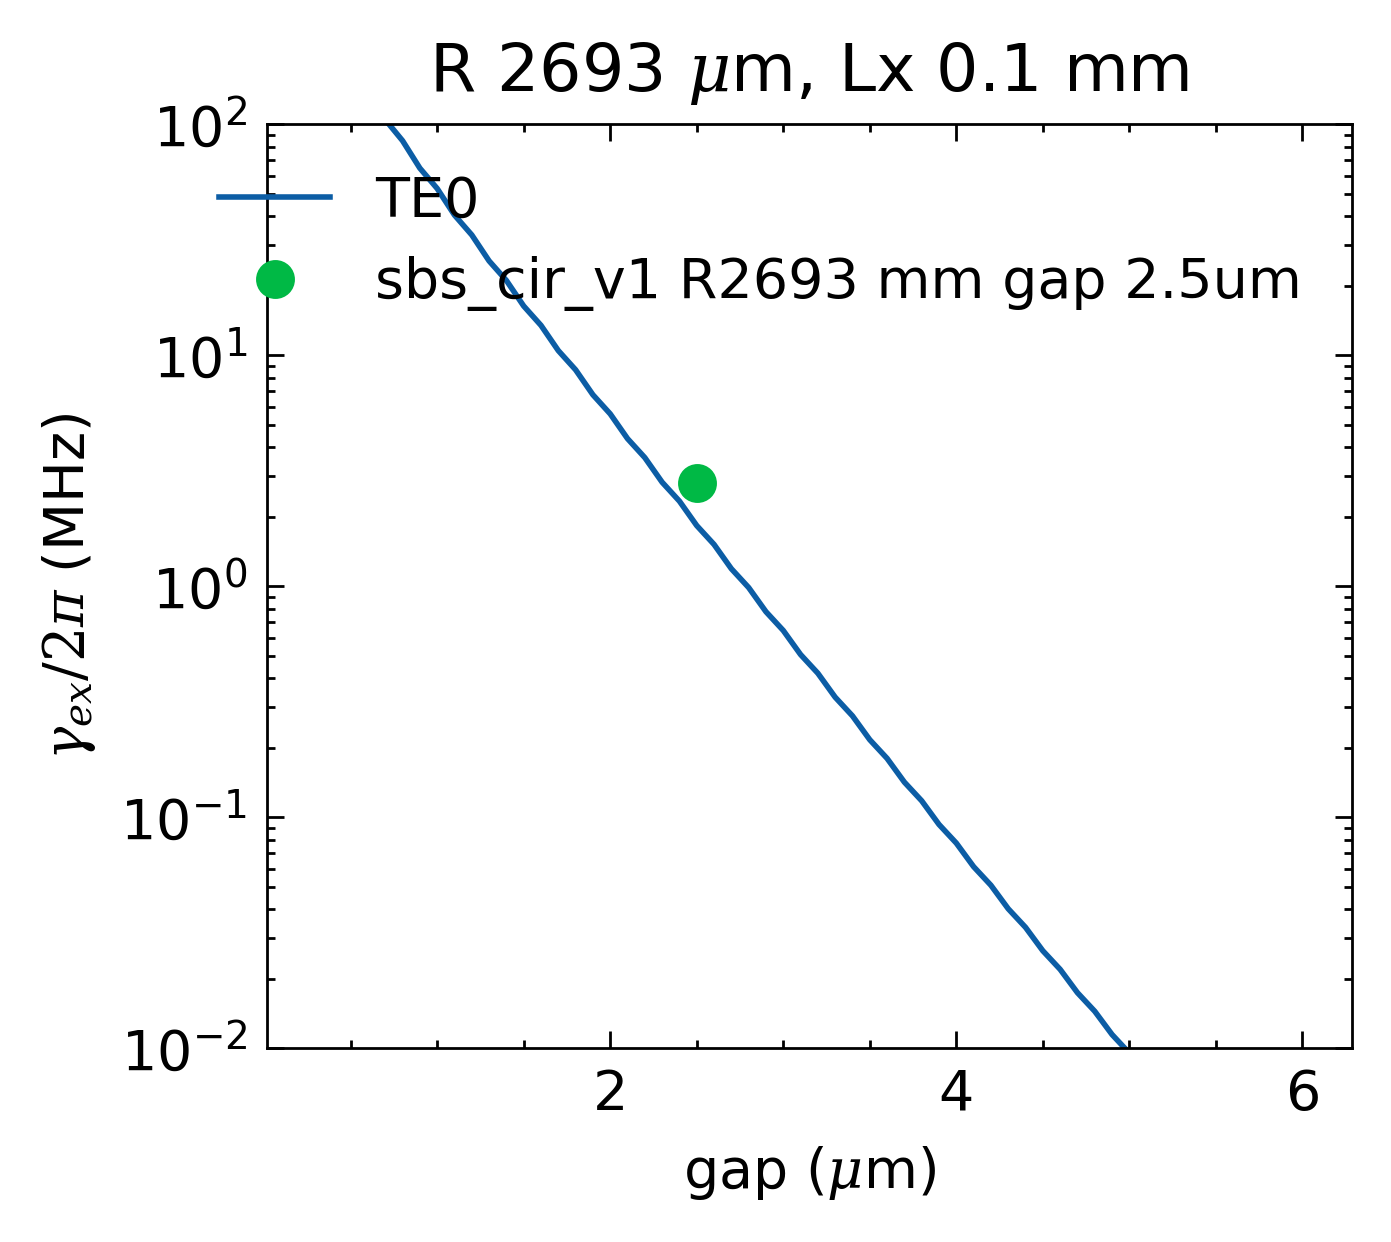

In [23]:
Lx = 0.1e-3
L = 2*np.pi*2693e-6

mode_list = ['TE0']
mode_ind = [WG_mode_dir[mode] for mode in mode_list]
ka2 = directional_coupler(dneff[mode_ind, :], Lx, wl)
r_ex = cavity_coupling_rate(ka2, ng, L)/(2*np.pi*1e6)

plt.figure()
plt.plot(gapx*1e6, 10*np.log10(ka2.T), label = mode_list[0])
plt.plot(2.5, -27.8, 'o', label = 'sbs_cir_v1 R2693 mm gap 2.5um');
plt.legend()
plt.xlabel(r'gap ($\mu$m)')
plt.ylabel(r'$\kappa^2$ (dB)')
plt.title(r'R 2693 $\mu$m, Lx ' + f'{Lx*1e3:.1f} mm')

plt.figure()
plt.semilogy(gapx*1e6, r_ex.T, label = mode_list[0])
plt.semilogy(2.5, 2.8, 'o', label = 'sbs_cir_v1 R2693 mm gap 2.5um')
plt.ylim((0.01, 100))
plt.legend()
plt.xlabel(r'gap ($\mu$m)')
plt.ylabel(r'$\gamma_{ex}/2\pi$ (MHz)')
plt.title(r'R 2693 $\mu$m, Lx ' + f'{Lx*1e3:.1f} mm')

#### $\kappa^2$ at gap 2.5 $\mu$m

Text(0.5, 1.0, 'Gap 2.5 $\\mu$m')

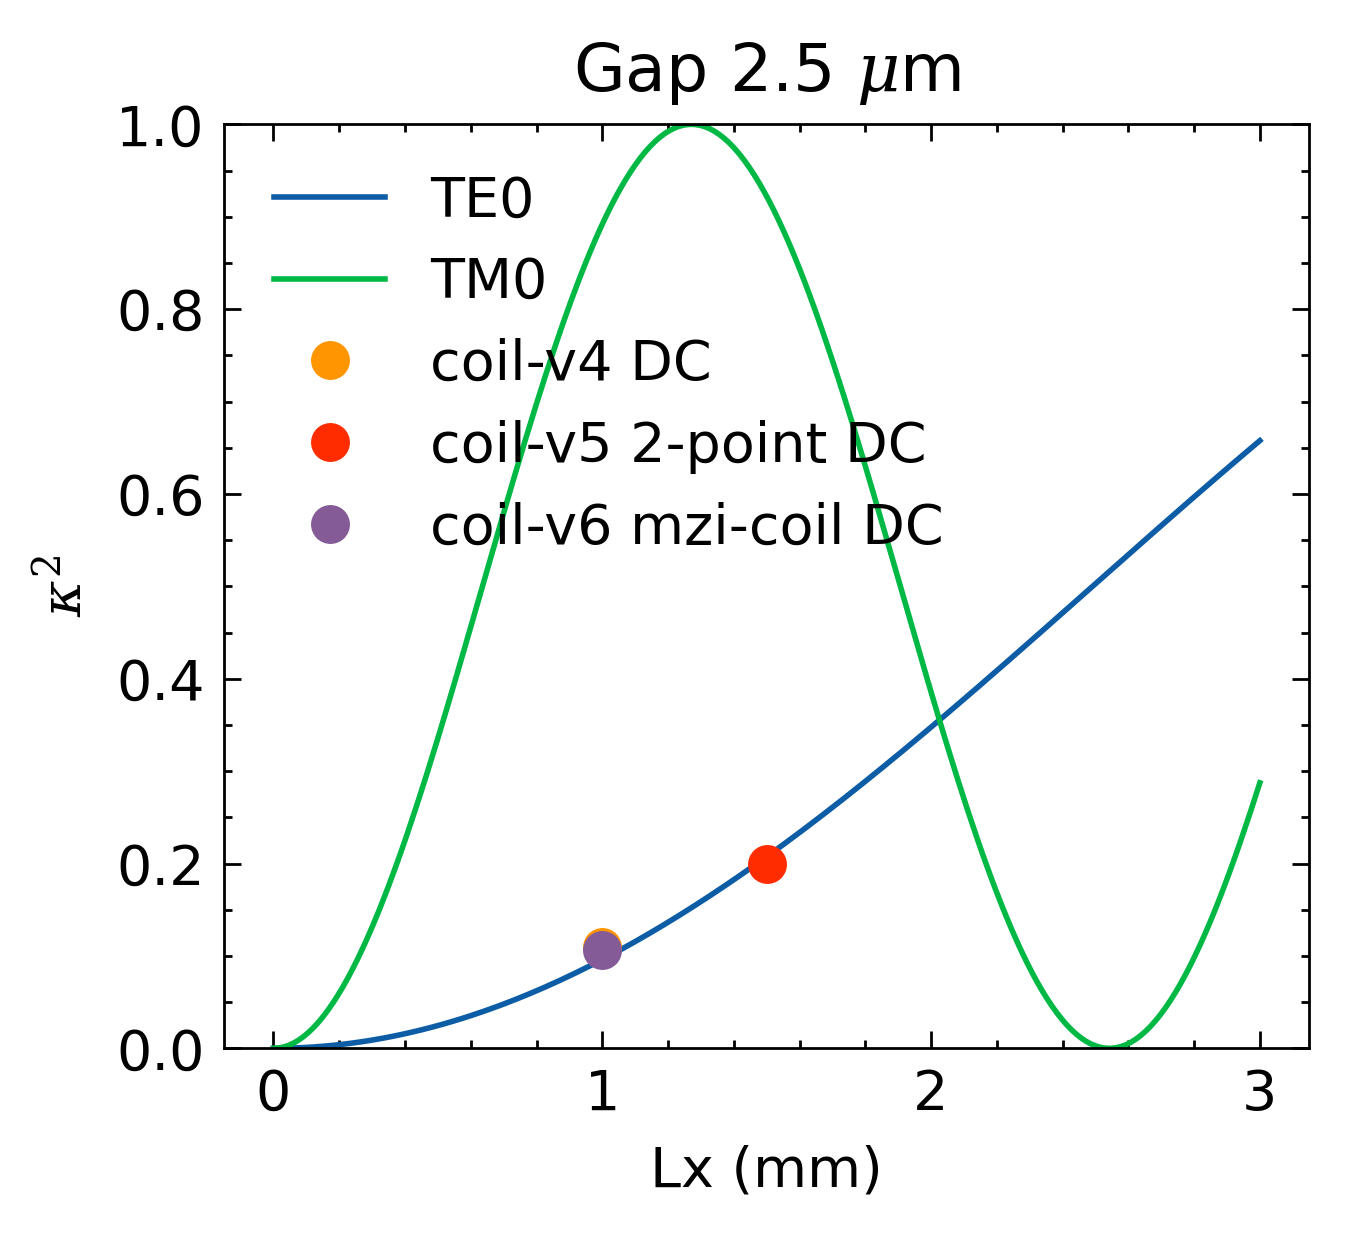

In [14]:
wl = 1550e-9
ng = 1.53
gap = 2.5e-6

WG_mode_dir = {'TE0': 0, 'TE1': 1, 'TM0': 2, 'TM1': 3}
mode_list = ['TE0', 'TM0']
mode_ind = [WG_mode_dir[mode] for mode in mode_list]

ind_gap = np.argmin(np.abs(gapx - gap))
Lx_sweep = np.linspace(0, 3e-3, 200)
ka2 = np.array([directional_coupler(dneff[ii, ind_gap], Lx_sweep, wl) for ii in mode_ind])

plt.figure()
plt.plot(Lx_sweep*1e3, ka2[0, :], label = mode_list[0])
plt.plot(Lx_sweep*1e3, ka2[1, :], label = mode_list[1])
plt.plot([1.0], [0.11], 'o', label = 'coil-v4 DC')
plt.plot([1.5], [0.20], 'o', label = 'coil-v5 2-point DC')
plt.plot([1.0], [0.106], 'o', label = 'coil-v6 mzi-coil DC')
plt.ylim((0, 1))
plt.legend()
plt.xlabel(r'Lx (mm)')
plt.ylabel(r'$\kappa^2$')
plt.title(r'Gap 2.5 $\mu$m')

#### $\kappa^2$ at gap 2.0 $\mu$m

Text(0, 0.5, '$\\kappa^2$')

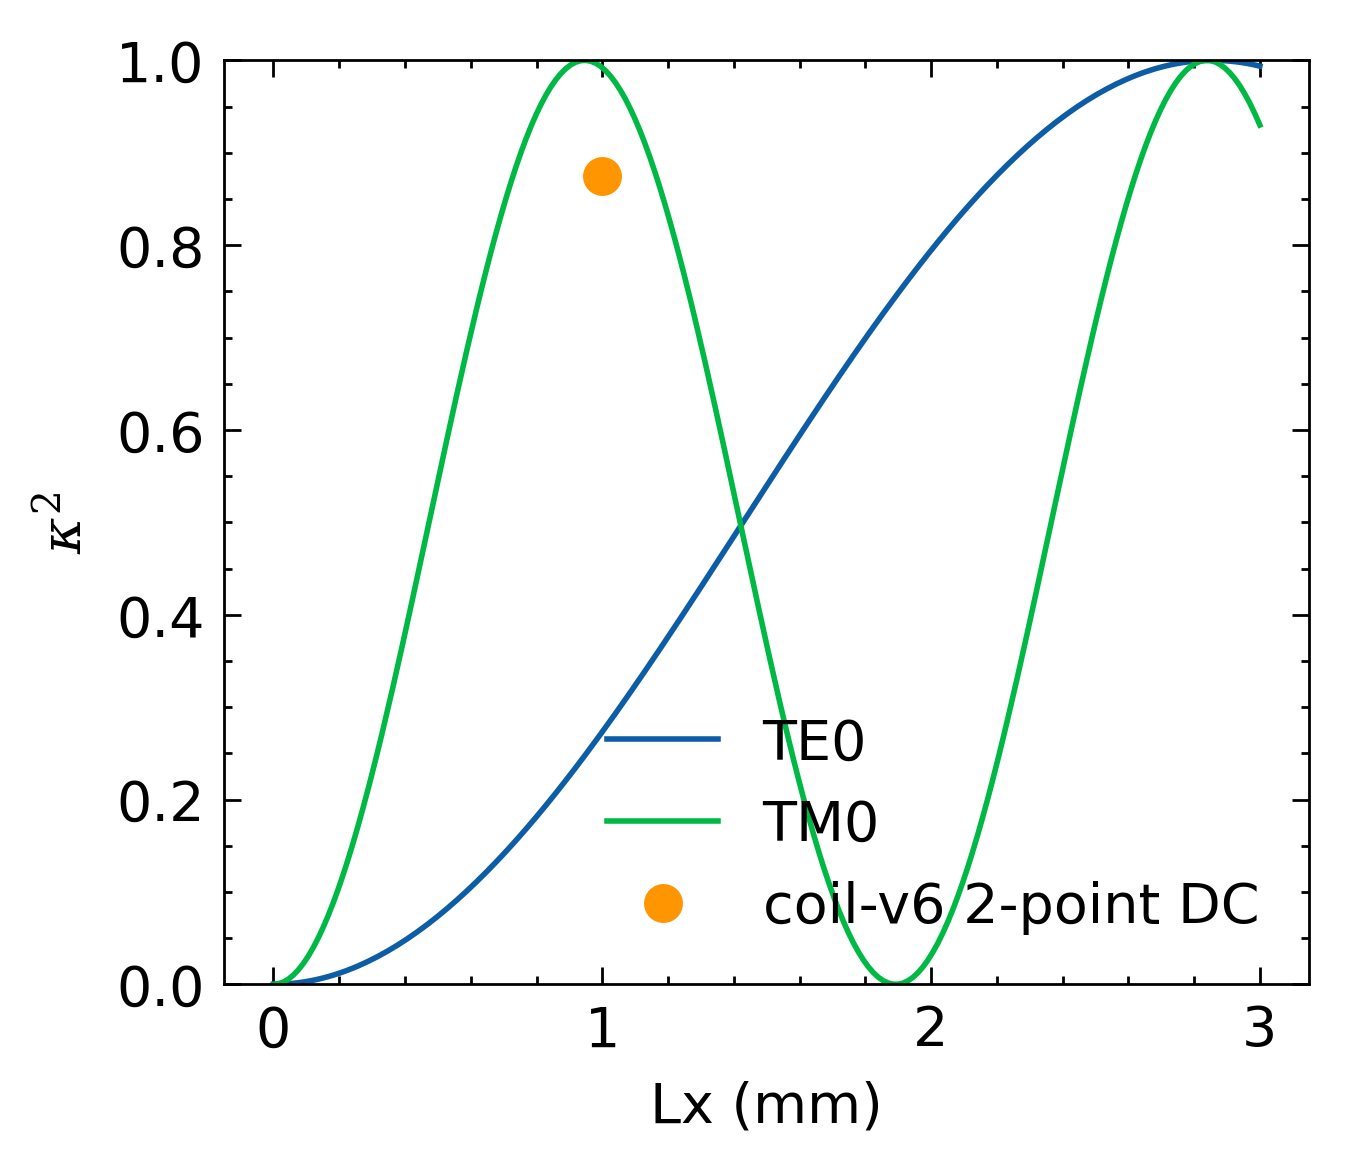

In [17]:
wl = 1550e-9
ng = 1.53
gap = 2.0e-6

ind_gap = np.argmin(np.abs(gapx - gap))
Lx_sweep = np.linspace(0, 3e-3, 200)
ka2 = np.array([directional_coupler(dneff[ii, ind_gap], Lx_sweep, wl) for ii in mode_ind])

plt.figure()
plt.plot(Lx_sweep*1e3, ka2[0, :], label = mode_list[0])
plt.plot(Lx_sweep*1e3, ka2[1, :], label = mode_list[1])
plt.plot([1.0], [0.875], 'o', label = 'coil-v6 2-point DC')
plt.ylim((0, 1))
plt.legend()
plt.xlabel(r'Lx (mm)')
plt.ylabel(r'$\kappa^2$')